In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Zakladni importy
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import sys

In [3]:
# Import vlastnich modulu
sys.path.append("../..")
import src.data.cube_domain as cb
import src.models.expert_discontinuous as ed
import src.models.mlp_model as mm
from src import train
from src import utils

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
L_BOUNDS = (0.0,)
U_BOUNDS = (2 * np.pi,)

In [6]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=1,
    N_int=1000,
    N_sides=[(0, 0)],
    device=device,
    time_dependant=False
)

domain = cb.CubeDomain(domain_ctx)


In [7]:
model_disc_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    input_dim=1,
    output_dim=1,
    last_layer_activation='disc',
    disc_steepness=30
)


model_smooth_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    input_dim=1,
    output_dim=1,
)

def char(x):
    return (x < np.pi/2).to(torch.float32)


model_disc = mm.MLPModel(model_disc_ctx).to(device)
model_smooth = mm.MLPModel(model_smooth_ctx).to(device)

optim_disc = torch.optim.Adam(model_disc.parameters(), lr=1e-4)
optim_smooth = torch.optim.Adam(model_smooth.parameters(), lr=1e-4)

In [8]:
def H(x):
    return torch.where(x < 0, 0, 1)

def f1(x):
    return x

def f2(x):
    return torch.sin(x)

def g(x):
    return char(x) * f1(x) + (1 - char(x)) * f2(x)

In [9]:
def loss(model: torch.nn.Module, domain: cb.CubeDomain):
    in_pts = domain.interior
    model_out = model(in_pts)
    g_out = g(in_pts)
    
    loss = torch.mean((model_out - g_out)**2)
    
    return [loss]

In [ ]:
train_ctx = train.TrainingContext(
    model=model_disc,
    optimizer=optim_disc,
    domain=domain,
    loss_fn=loss,
    epochs=10_000
)
losses_disc, _ = train.simple_train(train_ctx)

train_ctx.model = model_smooth
train_ctx.optimizer = optim_smooth
losses_smooth, _ = train.simple_train(train_ctx)

train_ctx.model = model_expts
train_ctx.optimizer = optim_expts
losses_expts, _ = train.simple_train(train_ctx)

Loss at epoch 1 is: 0.518169641494751. 
Loss at epoch 100 is: 0.25241997838020325. 
Loss at epoch 200 is: 0.15387733280658722. 
Loss at epoch 300 is: 0.14781054854393005. 
Loss at epoch 400 is: 0.14453597366809845. 
Loss at epoch 500 is: 0.12900270521640778. 
Loss at epoch 600 is: 0.11007602512836456. 
Loss at epoch 700 is: 0.0802573636174202. 
Loss at epoch 800 is: 0.04928497597575188. 
Loss at epoch 900 is: 0.03197702765464783. 
Loss at epoch 1000 is: 0.011615524999797344. 
Loss at epoch 1100 is: 0.0093288728967309. 
Loss at epoch 1200 is: 0.00799228623509407. 
Loss at epoch 1300 is: 0.004516148008406162. 
Loss at epoch 1400 is: 0.004364278167486191. 
Loss at epoch 1500 is: 0.004052513279020786. 
Loss at epoch 1600 is: 0.0034799021668732166. 
Loss at epoch 1700 is: 0.00385763100348413. 
Loss at epoch 1800 is: 0.0035121305845677853. 
Loss at epoch 1900 is: 0.0030702624935656786. 
Loss at epoch 2000 is: 0.0024756165221333504. 
Loss at epoch 2100 is: 0.0026515410281717777. 
Loss at epoc

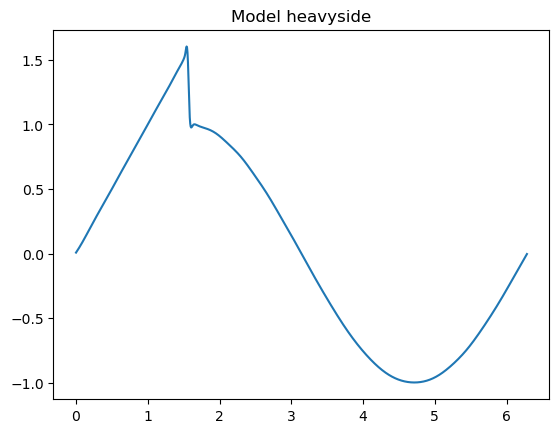

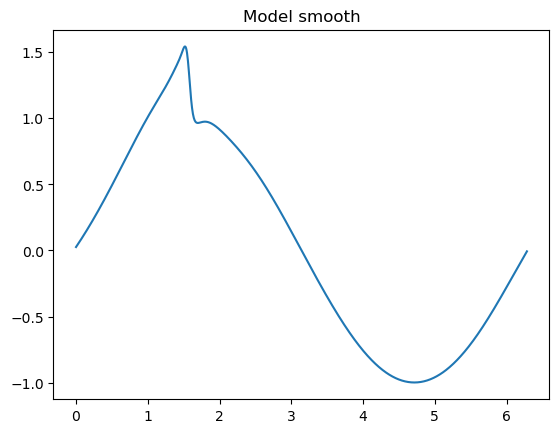

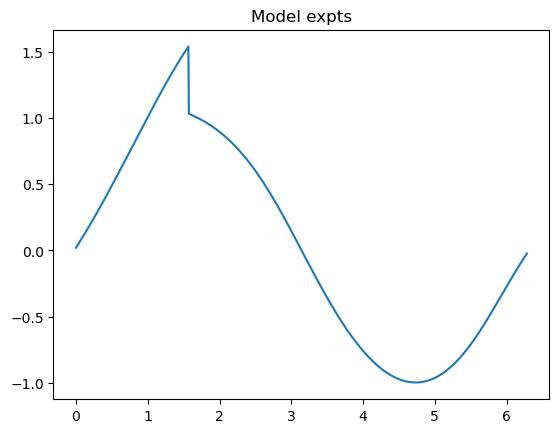

In [ ]:
import matplotlib.pyplot as plt

x = torch.linspace(0, 2*np.pi, 1000, device=device).unsqueeze(1)

y_disc = model_disc(x).detach().to('cpu')
y_smooth = model_smooth(x).detach().to('cpu')
y_expts = model_expts(x).detach().to('cpu')

y_g = g(x).detach().to('cpu')
x = x.detach().to('cpu')

fig_disc, ax_disc = plt.subplots()
fig_smooth, ax_smooth = plt.subplots()
fig_experts, ax_experts = plt.subplots()


ax_disc.set_title("Model heavyside")
ax_disc.plot(x, y_disc)

ax_smooth.set_title("Model smooth")
ax_smooth.plot(x, y_smooth)

ax_experts.set_title("Model expts")
ax_experts.plot(x, y_expts)

plt.show()


In [ ]:
for name, param in model_disc.named_parameters():
    if name == "network.6.jump_size":
        print(param)
    if name == "network.6.jump_centre":
        print(param)

Parameter containing:
tensor([1.0459, 0.9956, 1.0790, 1.0107, 1.0350, 0.9635, 1.0583, 1.0456, 1.0905,
        1.0712, 1.0186, 0.9840, 1.4062, 1.0054, 1.0354, 1.0117, 1.0067, 1.0342,
        1.1360, 0.9861, 0.9829, 1.2063, 1.0679, 1.0080, 1.0093, 1.0080, 1.0574,
        1.0791, 1.0014, 0.9953, 1.0158, 1.0100], device='cuda:0',
       requires_grad=True)
Parameter containing:
tensor([-0.0156,  0.0070,  0.0101,  0.0063, -0.0204,  0.0359, -0.0118, -0.0275,
         0.0156, -0.0183, -0.0364,  0.0135, -0.2145,  0.0158, -0.0076, -0.0097,
        -0.0034,  0.0055, -0.0194,  0.0065, -0.0424, -0.0759, -0.0010, -0.0039,
        -0.0226, -0.0055, -0.0302,  0.0204, -0.0028,  0.0090, -0.0083, -0.0299],
       device='cuda:0', requires_grad=True)
